# SageMath problems

Here is a collection of problems to explore the functionalities provided by SageMath.

* The first two problems cover material typically seen in the first year of an undergraduate curriculum in math, and are problems from calculus and linear algebra.
* The third problem supposes minimal knowledge of [Markov chains](https://en.wikipedia.org/wiki/Markov_chain), and combines probability and linear algebra.
* The last problem is the most advanded problem on this worksheet and explores the use of mathematical databases for research. The example given here is a known bijection between two famous combinatorial objects, but the point of view taken is that of a student who would hear about the objects for the first time and explore them. Researchers in combinatorics will still learn from this problem, perhaps on the theoretical side, and very likely on the computational side with the use of databases.

License: CC-BY-NC-SA. Free to reuse and modify for non-commercial purposes.
Author: Nadia Lafrenière

# A multivariable calculus problem: intersection of two surfaces

(a) Create a plot for the sphere of radius $3$, centered at the origin. Make the sphere relatively translucent, so that when we add the pictures together in part (d), we can see details of the inside.
    
(b) Create a plot for the cylinder given by implicit equation $(x-\frac{3}{2})^2 + y^2 = (\frac{3}{2})^2$. Make it grey. Again, make it relatively translucent.

(c) Find the equation of the curve of intersection of the sphere from part (a) and the cylinder from part (b). Your answer could be an equation or a list of equations.

(d) Draw on the same graph the curve of intersection, as well as the sphere from part (a) and the cylinder from part (b).

*Hint: the sphere of radius $r$ centered at $(a,b,c)$ has equation $(x-a)^2+(y-b)^2+(z-c)^2=r^2$.*

# Solving systems of equations

(a)  What are all the values of $a$ for which the following system does not have a unique solution? You can use whatever method you want, but you should justify it.
$$ \left(\begin{array}{rrrr}
a & 1 & 2 & 3 \\
1 & a & 2 & 3 \\
1 & 2 & a & 3 \\
1 & 2 & 3 & a
\end{array}\right)\cdot
\left(\begin{array}{r}
v_1\\ v_2\\v_3\\v_4
\end{array}\right) = \left(\begin{array}{r}
1 \\ 2\\ 3\\ 4
\end{array}\right).$$

(b) Find the solution to the following systems of equation: 
$$\left\{\begin{array}{c} x^2+3y^2+2z^2=1\\ 2x+3y+4z=0 \end{array}\right..$$

(c) Verify your answer from part (b) by displaying the surfaces corresponding to each equation in your system. The intersection of the two surfaces should be the solution to your system of equations.

# Median time of a random walk through simulation and a Markov chain

## Snakes and ladders!
Snakes and ladders is a game involving rolling a dice. At each turn, the player rolls the dice and advances the number of cells that is shown on the dice. If the player reaches a cell which is the base of a ladder, the player has to climb up that ladder and if they reach a cell that is the top of the snake, they have to go down to the bottom of the snake without a dice throw. The player who reaches the last cell first wins the game.

An example of a (small) snakes and ladders grid is displayed here.

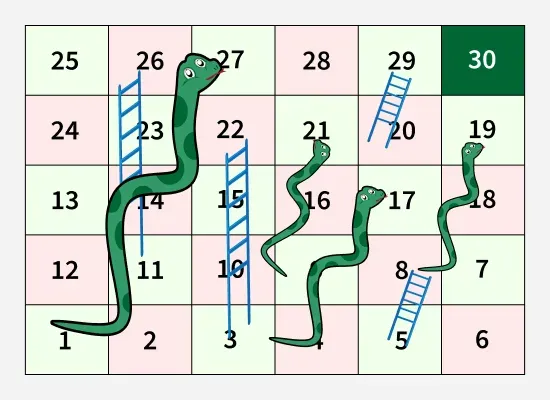

(Picture credit: Geeks for geeks)


We can show, for example, that a very lucky player could win the game with just three rolls.

However, since most players are not that lucky, a reasonable question to ask is how long does a game last, either in average, or just the median game?

 * The average time is given by $\sum_{n\geq 0} n\ p(n)$, where $p(n)$ is the probability that the game is won with $n$ rolls.
    
 * The median time is given as the value of $n$ for which there is the same probability of finishing before $n$ rolls or after at least $n$ rolls. 

The median time is less sensitive to the impact of a very long game.

(a) Use a simulation where 100 games of snakes and ladders are played, and find the (experimental) median number of rolls. This is the number $k$ for which there is 50 games that took less than or equal to $k$ turns and 50 games took more than or equal to $k$ turns. $k$ is either an integer, or the average of two integers. The easiest ways to find the median when there are 100 attempts are either to sort the data and get the average of the 50th and 51st value, or to use `median(L)` for a list `L`.

*Hint*: for simulations, useful functions include `random`, `randint` and `uniform`. I invite you to read the documentation for these functions.

(b) Build the transition matrix of the Markov chain corresponding to the snakes and ladders game. The states are the cells on the board, and the transitions are given by the probability of moving from one cell to another in one roll of dice. Make sure that the matrix you created is stochastic. (You do not have to display the matrix.)

*Hint*: for this problem, if is highly recommended that you test your code with a smaller matrix. You can design an easy board of snakes and ladders with 15 cells, two snakes and two ladders, for example, and make sure that you get the right thing.

(c) Using the transition matrix, find the median time it takes to finish a game: this is the smallest value of $n$ for which there is a probability at least 50% of having hit the last cell in $k$ rolls of the dice.

*Remark*: To get to the last cell, one must roll the exact value that would make the player land on that cell. For example, if a player is at cell $28$ and wants to reach $30$, they must roll a $2$. If they roll a $1$, they land on $29$ and they have to roll a $1$ again. If they roll $3$ or higher, they stay in place at $28$ until the next turn.


In [3]:
# Snakes and ladders board
n = 30
snakes_30 = [(27,1), (21,9), (19,8), (17,3)]
ladders_30 = [(11,26), (3,22), (20,29), (5,8)]

# One can use this code to check that a matrix is stochastic
def is_stochastic_matrix(M):
    l = M.nrows()
    return ([sum(_ for _ in M.row(i)) for i in range(l)] == [1 for i in range(l)]
            and all(entry >= 0 for row in M for entry in row))

# Combinatorics using mathematical databases

The problems below use the databases OEIS and FindStat to identify an equivariant bijection between two classes of combinatorial objects.

Further information on the use of databases in SageMath can be found in the [Sage Reference Manual](https://doc.sagemath.org/html/en/reference/databases/index.html) or in the notebook on databases for experimental math posted with this file.

In [1]:
# These two lines are needed for the execution of FindStat code with SageMath
from sage.databases.findstat import *
findstat()._allow_execution = True

## Problem 1: Mountain ranges

We consider *paths* that have up-steps $(1,1)$ and down-steps $(1,-1)$ in the cartesian plane. Paths start at the origin and move right, going either up or down. Paths have finite length.

A path is a *mountain range*, if it lies in the first quadrant (including the positive $x$-axis), and ends on the $x$-axis.

For example, both paths below have three up-steps and three down-steps, but only the first one is a mountain range.
    
       /\
    /\/  \    /\
                \/\/

(a) Count the number of mountain ranges with $n$ up-steps and $n$ down-steps, for integer values of $n$ between $1$ and $8$. For this part, it is recommended that you define a function that, given a path, determines if it is a mountain range. You should also define a function that creates all paths.

(b) Use the OEIS to recognize the integer sequence that you get. Read the comments (`oeis(xxxx).comments()`, where `xxxx` is the sequence ID) to find the proper name of the mountain ranges. This is found in one of the first few comments.

## Problem 2: Ballot problem
Suppose there is an election in which there are two candidates $A$ and $B$, and assume that $A$ and $B$ each receive $n$ votes. Ballots are counted successively, one after the other, and the results are published after each ballot is revealed.

(a) How likely is it that $A$ was ahead of $B$ (or equal to $B$) the whole time while the ballots were counted? Your answer should be a probability that depends on $n$. Give that probability for values of $n$ between $1$ and $10$.

(b) Now suppose that $A$ and $B$ each received $100$ votes. How likely is it that $A$ was ahead of $B$ (or equal to $B$) the whole time?

## Problem 3: Two-row, two-way increasing tables
An *integer partition* $\lambda$ of $n$ is a weakly decreasing sequence $\lambda_1 \geq \lambda_2\geq \ldots\geq \lambda_k\geq 0$ of positive integers whose sum is $n$.

Given an integer partition $\lambda$, its diagram is a collection of boxes, with $\lambda_1$ boxes in the first row (at the top), $\lambda_2$ in the second row (just below), etc.

A *table* is a filling of the diagram with positive integers, with one integer in each box. A table is *two-way increasing* if it contains the entries $\{1,2,\ldots,n\}$ and if the entries in the boxes are increasing along the rows, left to right, and down the columns, top to bottom.

For example, here are the five two-way increasing tables of shape $\lambda = (3,3)$:


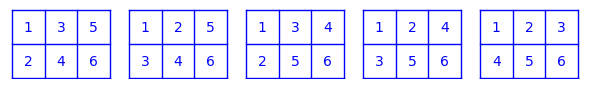

(a) Count the number of two-way increasing tables of shape $(n,n)$ for integer values of $n$ between $1$ and $8$.

(b) Use the comments from the OEIS (entry at index 42) to find the proper name for two-way increasing tables.

(c) Count the number of two-way increasing tables of shape $(n,n-1)$ for integer values of $n$ between $1$ and $8$. Explain the result you get.

## Problem 4: Correspondence between two-row, two-way increasing tables and mountain ranges

Since the number of two-way increasing tables of shape $(n,n)$ and the number of mountain ranges with $n$ up-steps and $n$ down-steps is the same, it is natural to ask if there is a *bijection* between them, which is an invertible function on the domain of mountain ranges and image of two-way increasing tables of shape $(n,n)$. We will do so with the help of the FindStat database.

(a) List all collections in FindStat, and find the exact name and the collection ID, of mountain ranges and two-way increasing tables. You should use the names you learned from the OEIS. To list the collections in FindStat, start typing `FindStat`  and then hit `Tab` to see what commands are available.

(b) Look at all the maps from mountain ranges to two-way increasing tables. Use the command `findmap` to do so. There should be a unique interesting map.

(c) For each mountain ranges with 4 up-steps and 4 down-steps, find the corresponding two-way increasing table with 4 entries in each row.  This is the result of the map found in part (b). Then, using `object.pp()`, where object is a given mountain range or table, describe this correspondance as a drawing. Express your answer in the format:
      
      /\/\/\/\
    
      1  3  5  7
      2  4  6  8

The *area* of a mountain range is obtained by first tilting the range 45 degrees counterclockwise, and then counting the number of full squares above the $y=x$-axis and below the path. The triangles right above the axis do not count. Below is an illustrated example, where the full squares have been marked with `x`.
      
                        _____
          /\/\        _| x x 
         /    \      | x x  .
        /      \     | x  . .
                     |  . . .

(d) For each two-way increasing table of shape $(4,4)$, print the value of the area under the corresponding mountain range. *Hint*: the name of the corresponding FindStat statistic is `area`.

(e) The latter is a statistic in FindStat on two-way increasing tables. Can you find that statistic?

*Remark*: This means that the bijection you found between mountain ranges and two-row, two-way increasing tables is statistic-preserving. In other words, you could "see" the area directly in the table. *Extra problem* (optional, probably harder): Explain that correspondence.